This notebook produces Figure S1, which is histograms of |gamma1|-|gamma2| for each surface type across our ROI.
<br>
<br>
Use the "earthscope_insar" conda environment as the Python kernel.
***

In [11]:
#import necessary packages
from osgeo import gdal
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as patches
from matplotlib.colors import ListedColormap
%matplotlib  widget

In [12]:
# load average coherence (average gamma1 and average gamma2)
saveDir_avg = '../../2_Calculating_coherence_2_ways/'

fileNameAvg_1 = 'avg_coh_method1.r4'  
f1 = gdal.Open(saveDir_avg + fileNameAvg_1, gdal.GA_ReadOnly)  #check correct directory
coh_avg_m1 = f1.ReadAsArray()
f1 = None

fileNameAvg_2 = 'avg_coh_method2.r4'  
f2 = gdal.Open(saveDir_avg + fileNameAvg_2, gdal.GA_ReadOnly)  #check correct directory
coh_avg_m2 = f2.ReadAsArray()
f2 = None

#calculate differences between method 1 and method 2
capped_m2 = np.where(coh_avg_m2 > 0.8475, 0.8475, coh_avg_m2)
diff_avg = coh_avg_m1 - capped_m2
diff = coh_avg_m1 - coh_avg_m2

In [13]:
# define dimensions of the full resolution image/area
dx= 9000; dy=1575

# this is the aspect ratio for plotting that maintains the geographic aspect ratio for visual similarity 
# I used Google Earth to measure the height and width of the ROI in km, this can be updated for other ROIs in a similar way.
aspect_rat = (21.8/dy) / (34.44/dx) 

In [14]:
# Define the focus areas to outline 
imperial_road = [6820, 100, 7520, 450]
transect_roads = [4500, 650, 6600, 1000]     
ElCentro_airport = [4575, 985, 5275,1260]
pools = [7700,300, 8400, 650]
imperial_airport = [6600,800,7300,1075]

In [15]:
#load in the road and no_desert masks to separate pixels into surface types 
f1 = gdal.Open('../Figure_3_surface_types_map/roadarray.r4', gdal.GA_ReadOnly)
roads = f1.ReadAsArray()+1 
f1 = None
f1 = gdal.Open('../Figure_3_surface_types_map/no_desert.r4', gdal.GA_ReadOnly)
no_desert = f1.ReadAsArray() 
no_desert_flipped = np.where(no_desert==1,0,1)
f1 = None
updated_roads = no_desert_flipped * roads
no_desert_mask = np.where(updated_roads==2,1,0)
NVG_mask = roads-1

In [16]:
# make masks for each surface type, but just with 1's and 0's 
all_ROI_mask = np.ones((dy,dx),dtype='float')
all_nondesert_mask = np.where(no_desert_flipped==1,1,0)
urban_barren_nondesert_mask = np.where(no_desert_mask==1,1,0)
just_veg_mask = np.where(NVG_mask==0,1,0)
just_desert_mask = (np.where(no_desert_flipped==0,1,0))

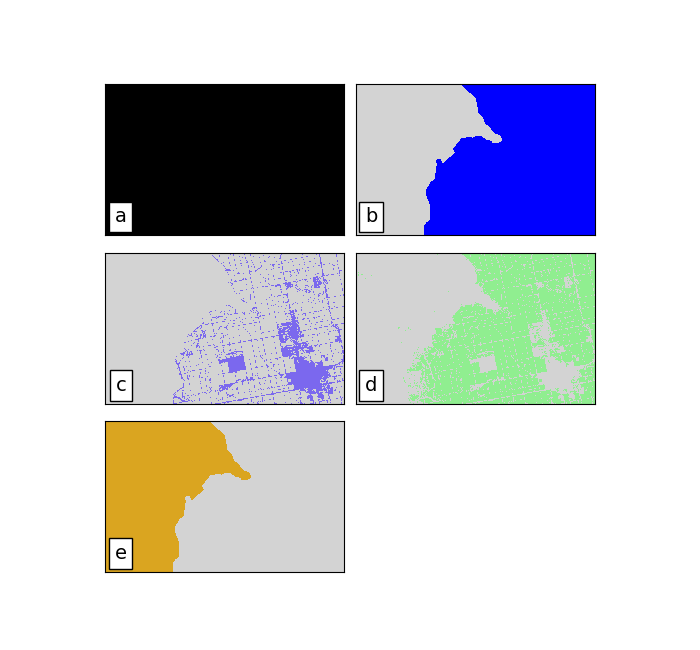

In [17]:
# plot each mask for each surface type 

label_x = 0.09
label_y = 0.06
props = dict(boxstyle='square',facecolor='white',edgecolor='black')

fig, axs = plt.subplots(3,2,figsize=(7,6.5)) # figsize just has to be big enough to accomodate the aspect ratio!!!
plt.subplots_adjust(wspace=0.05,hspace=0.03,left=0.15,right=0.85)

ax = axs[0,0]
cols = ['lightgray','black']; cmap_temp = ListedColormap(cols)
im = ax.imshow(all_ROI_mask,interpolation ='none',cmap=cmap_temp,vmin=0,vmax=1)
ax.set_aspect(aspect_rat)
ax.set_xlim(dx,0)
ax.set_xticks([]); ax.set_yticks([])
ax.text(label_x, label_y, 'a', bbox=props, fontsize=14,
        ha='right', va='bottom', transform=ax.transAxes)

ax = axs[0,1]
cols = ['lightgray','blue']; cmap_temp = ListedColormap(cols)
im = ax.imshow(all_nondesert_mask,interpolation ='none',cmap=cmap_temp,vmin=0,vmax=1)
ax.set_aspect(aspect_rat)
ax.set_xlim(dx,0)
ax.set_xticks([]); ax.set_yticks([])
ax.text(label_x, label_y, 'b', bbox=props, fontsize=14,
        ha='right', va='bottom', transform=ax.transAxes)

ax = axs[1,0]
cols = ['lightgray','mediumslateblue']; cmap_temp = ListedColormap(cols)
im = ax.imshow(urban_barren_nondesert_mask,interpolation ='none',cmap=cmap_temp,vmin=0,vmax=1)
ax.set_aspect(aspect_rat)
ax.set_xlim(dx,0)
ax.set_xticks([]); ax.set_yticks([])
ax.text(label_x, label_y, 'c', bbox=props, fontsize=14,
        ha='right', va='bottom', transform=ax.transAxes)

ax = axs[1,1]
cols = ['lightgray','lightgreen']; cmap_temp = ListedColormap(cols)
im = ax.imshow(just_veg_mask,interpolation ='none',cmap=cmap_temp,vmin=0,vmax=1)
ax.set_aspect(aspect_rat)
ax.set_xlim(dx,0)
ax.set_xticks([]); ax.set_yticks([])
ax.text(label_x, label_y, 'd', bbox=props, fontsize=14,
        ha='right', va='bottom', transform=ax.transAxes)

ax = axs[2,0]
cols = ['lightgray','goldenrod']; cmap_temp = ListedColormap(cols)
im = ax.imshow(just_desert_mask,interpolation ='none',cmap=cmap_temp,vmin=0,vmax=1)
ax.set_aspect(aspect_rat)
ax.set_xlim(dx,0)
ax.set_xticks([]); ax.set_yticks([])
ax.text(label_x, label_y, 'e', bbox=props, fontsize=14,
        ha='right', va='bottom', transform=ax.transAxes)

axs[2,1].axis('off')

plt.show()
#plt.savefig('Supp_masks.png',transparent=True,bbox_inches='tight',dpi=500)

In [18]:
# pull out the coherence difference values within each surface type, 
# and flatten the arrays to prepare them for histogram plotting

all_nondesert = (np.where(no_desert_flipped==1,diff,np.nan))
all_nondesert_flat = all_nondesert[~np.isnan(all_nondesert)]

urban_barren_nondesert = (np.where(no_desert_mask==1,diff,np.nan))
urban_barren_nondesert_flat = urban_barren_nondesert[~np.isnan(urban_barren_nondesert)]

just_veg = (np.where(NVG_mask==0,diff,np.nan))
just_veg_flat = just_veg[~np.isnan(just_veg)]

just_desert = (np.where(no_desert_flipped==0,diff,np.nan))
just_desert_flat = just_desert[~np.isnan(just_desert)]

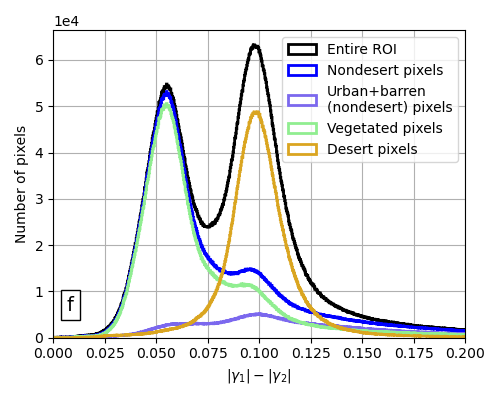

In [19]:
# plot histograms of the coherence differences for each surface type. Colors correspond to masks above.

plt.figure(figsize=(5,4),tight_layout=True)
bins1 = np.linspace(0,0.2,750)
plt.hist(diff.flatten(),bins=bins1,histtype='step',color='k',linewidth=2,label='Entire ROI')
plt.hist(all_nondesert_flat,bins1,histtype='step',color='b',linewidth=2,label='Nondesert pixels')
plt.hist(urban_barren_nondesert_flat,bins1,histtype='step',color='mediumslateblue',linewidth=2,label='Urban+barren\n(nondesert) pixels')
plt.hist(just_veg_flat,bins1,histtype='step',color='lightgreen',linewidth=2,label='Vegetated pixels')
plt.hist(just_desert_flat,bins1,histtype='step',color='goldenrod',linewidth=2,label='Desert pixels')
plt.ylabel('Number of pixels')
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.xlabel('$|\gamma_{1}|-|\gamma_{2}|$')
plt.legend()
plt.text(0.01, 0.5e4, 'f', bbox=props, fontsize=14,
        ha='right', va='bottom')
plt.grid()
plt.xlim(0,0.2)
plt.show()
#plt.savefig('Supp_hists.png', transparent=True, bbox_inches='tight',dpi=500)